## 1. Imports


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os, warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, brier_score_loss,
                             confusion_matrix, roc_curve)

import cricket_utils
from cricket_utils import (TEAM_RENAME, ACTIVE_TEAMS, CAT_COLS, NUM_COLS, FEATURE_COLS,
                           normalize_teams, build_preprocessor, build_match_state,
                           balls_to_overs_text)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

## 2. Load the data

In [8]:
matches = pd.read_csv('~/Downloads/matches.csv')
deliveries = pd.read_csv('~/Downloads/deliveries.csv')

print('matches   :', matches.shape)
print('deliveries:', deliveries.shape)
matches.head()

matches   : (756, 18)
deliveries: (179078, 21)


,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [10]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN


In [12]:
print(matches.dtypes)
print()
print(deliveries.dtypes)

id                 int64
Season               str
city                 str
date                 str
team1                str
team2                str
toss_winner          str
toss_decision        str
result               str
dl_applied         int64
winner               str
win_by_runs        int64
win_by_wickets     int64
player_of_match      str
venue                str
umpire1              str
umpire2              str
umpire3              str
dtype: object

match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batsman               str
non_striker           str
bowler                str
is_super_over       int64
wide_runs           int64
bye_runs            int64
legbye_runs         int64
noball_runs         int64
penalty_runs        int64
batsman_runs        int64
extra_runs          int64
total_runs          int64
player_dismissed      str
dismissal_kind        str
fielder        

In [14]:
matches.describe(include='all').T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,756.0,NaN,NaN,NaN,1792.178571,3464.478148,1.0,189.75,378.5,567.25,11415.0
Season,756,12,IPL-2013,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,749,32,Mumbai,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,756,546,08-04-2017,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team1,756,15,Mumbai Indians,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team2,756,15,Royal Challengers Bangalore,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_winner,756,15,Mumbai Indians,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
toss_decision,756,2,field,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
result,756,3,normal,743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dl_applied,756.0,NaN,NaN,NaN,0.025132,0.15663,0.0,0.0,0.0,0.0,1.0


## 3. Data quality audit


In [ ]:
def missing_report(df, name):
    missing = df.isna().sum()
    report = pd.DataFrame({
        'missing': missing,
        'missing_pct': (missing / len(df) * 100).round(2)
    })
    report = report[report['missing'] > 0].sort_values('missing', ascending=False)
    print(f'--- {name} ({len(df)} rows) ---')
    print(report if len(report) else 'no missing values')
    print()
    return report

_ = missing_report(matches, 'matches')
_ = missing_report(deliveries, 'deliveries')

--- matches (756 rows) ---
                 missing  missing_pct
umpire3              637        84.26
city                   7         0.93
winner                 4         0.53
player_of_match        4         0.53
umpire1                2         0.26
umpire2                2         0.26

--- deliveries (179078 rows) ---
                  missing  missing_pct
fielder            172630        96.40
player_dismissed   170244        95.07
dismissal_kind     170244        95.07



In [19]:
print('Duplicate match ids       :', matches['id'].duplicated().sum())
print('Exact duplicate delivery rows:', deliveries.duplicated().sum())
print()
print('result column:'); print(matches['result'].value_counts())
print()
print('dl_applied column:'); print(matches['dl_applied'].value_counts())
print()
print('innings present in deliveries:'); print(deliveries['inning'].value_counts())

Duplicate match ids       : 0
Exact duplicate delivery rows: 23

result column:
result
normal       743
tie            9
no result      4
Name: count, dtype: int64

dl_applied column:
dl_applied
0    737
1     19
Name: count, dtype: int64

innings present in deliveries:
inning
1    92742
2    86240
3       50
4       38
5        8
Name: count, dtype: int64


### Reading the missing values


In [ ]:

print(matches[matches['winner'].isna()][['id','Season','team1','team2','result','dl_applied']])

        id    Season                        team1  \
300    301  IPL-2011             Delhi Daredevils   
545    546  IPL-2015  Royal Challengers Bangalore   
570    571  IPL-2015             Delhi Daredevils   
744  11340  IPL-2019  Royal Challengers Bangalore   

                           team2     result  dl_applied  
300                Pune Warriors  no result           0  
545             Rajasthan Royals  no result           0  
570  Royal Challengers Bangalore  no result           0  
744             Rajasthan Royals  no result           0  


In [ ]:

print(matches[matches['city'].isna()][['id','Season','venue']])

      id    Season                                venue
461  462  IPL-2014  Dubai International Cricket Stadium
462  463  IPL-2014  Dubai International Cricket Stadium
466  467  IPL-2014  Dubai International Cricket Stadium
468  469  IPL-2014  Dubai International Cricket Stadium
469  470  IPL-2014  Dubai International Cricket Stadium
474  475  IPL-2014  Dubai International Cricket Stadium
476  477  IPL-2014  Dubai International Cricket Stadium


In [ ]:

print('Is winner always one of the two teams in the match?')
bad_winner = matches.dropna(subset=['winner']).apply(
    lambda r: r['winner'] not in [r['team1'], r['team2']], axis=1).sum()
print('  rows where winner is not team1 or team2:', bad_winner)

print()
print('over range :', deliveries['over'].min(), '-', deliveries['over'].max())
print('ball range :', deliveries['ball'].min(), '-', deliveries['ball'].max())
print()
print('Counts of ball numbers above 6:')
print(deliveries.loc[deliveries['ball'] > 6, 'ball'].value_counts().sort_index())

Is winner always one of the two teams in the match?
  rows where winner is not team1 or team2: 0

over range : 1 - 20
ball range : 1 - 9

Counts of ball numbers above 6:
ball
7    5113
8     795
9     122
Name: count, dtype: int64


## 4. Team name normalization


In [31]:
print('Unique team names in matches:')
for team in sorted(set(matches['team1']) | set(matches['team2'])):
    n = ((matches['team1'] == team) | (matches['team2'] == team)).sum()
    seasons = sorted(matches.loc[(matches['team1'] == team) | (matches['team2'] == team),
                                 'Season'].unique())
    print(f'  {team:32s} {n:4d} matches   {seasons[0]} - {seasons[-1]}')

Unique team names in matches:
  Chennai Super Kings               164 matches   IPL-2008 - IPL-2019
  Deccan Chargers                    75 matches   IPL-2008 - IPL-2012
  Delhi Capitals                     16 matches   IPL-2019 - IPL-2019
  Delhi Daredevils                  161 matches   IPL-2008 - IPL-2018
  Gujarat Lions                      30 matches   IPL-2016 - IPL-2017
  Kings XI Punjab                   176 matches   IPL-2008 - IPL-2019
  Kochi Tuskers Kerala               14 matches   IPL-2011 - IPL-2011
  Kolkata Knight Riders             178 matches   IPL-2008 - IPL-2019
  Mumbai Indians                    187 matches   IPL-2008 - IPL-2019
  Pune Warriors                      46 matches   IPL-2011 - IPL-2013
  Rajasthan Royals                  147 matches   IPL-2008 - IPL-2019
  Rising Pune Supergiant             16 matches   IPL-2017 - IPL-2017
  Rising Pune Supergiants            14 matches   IPL-2016 - IPL-2016
  Royal Challengers Bangalore       180 matches   IPL-2008 -

In [34]:
print('TEAM_RENAME mapping from cricket_utils.py:')
for old, new in TEAM_RENAME.items():
    print(f'  {old:28s} -> {new}')
print()
print('Teams kept for modelling:')
for t in ACTIVE_TEAMS:
    print('  ', t)

TEAM_RENAME mapping from cricket_utils.py:
  Delhi Daredevils             -> Delhi Capitals
  Deccan Chargers              -> Sunrisers Hyderabad
  Rising Pune Supergiants      -> Rising Pune Supergiant

Teams kept for modelling:
   Chennai Super Kings
   Delhi Capitals
   Kings XI Punjab
   Kolkata Knight Riders
   Mumbai Indians
   Rajasthan Royals
   Royal Challengers Bangalore
   Sunrisers Hyderabad


## 5. Cleaning the match table



In [ ]:
matches_clean = matches.copy()
start_rows = len(matches_clean)
matches_clean = matches_clean[matches_clean['winner'].notna()]
print(f'Dropped {start_rows - len(matches_clean)} abandoned matches (no result)')
before = len(matches_clean)
matches_clean = matches_clean[matches_clean['dl_applied'] == 0]
print(f'Dropped {before - len(matches_clean)} D/L matches (revised targets)')
matches_clean['city'] = matches_clean['city'].fillna('Dubai')
print('Filled 7 missing cities with "Dubai" (taken from the venue column)')
matches_clean = matches_clean.drop(columns=['umpire3'])
print('Dropped umpire3 column')
matches_clean = normalize_teams(matches_clean, ['team1', 'team2', 'toss_winner', 'winner'])
before = len(matches_clean)
matches_clean = matches_clean[matches_clean['team1'].isin(ACTIVE_TEAMS) &
                              matches_clean['team2'].isin(ACTIVE_TEAMS)]
print(f'Dropped {before - len(matches_clean)} matches involving short-lived franchises')

print()
print('Matches remaining:', len(matches_clean))

Dropped 4 abandoned matches (no result)
Dropped 19 D/L matches (revised targets)
Filled 7 missing cities with "Dubai" (taken from the venue column)
Dropped umpire3 column
Dropped 110 matches involving short-lived franchises

Matches remaining: 623


In [ ]:

deliveries_clean = deliveries.drop_duplicates().copy()
print('Dropped', len(deliveries) - len(deliveries_clean), 'exact duplicate delivery rows')

deliveries_clean = normalize_teams(deliveries_clean, ['batting_team', 'bowling_team'])
delivery_teams = set(deliveries_clean['batting_team']) | set(deliveries_clean['bowling_team'])
print('Team names in deliveries not present in matches:',
      delivery_teams - (set(matches_clean['team1']) | set(matches_clean['team2'])))

Dropped 23 exact duplicate delivery rows
Team names in deliveries not present in matches: {'Kochi Tuskers Kerala', 'Rising Pune Supergiant', 'Gujarat Lions', 'Pune Warriors'}


## 6. Exploratory data analysis


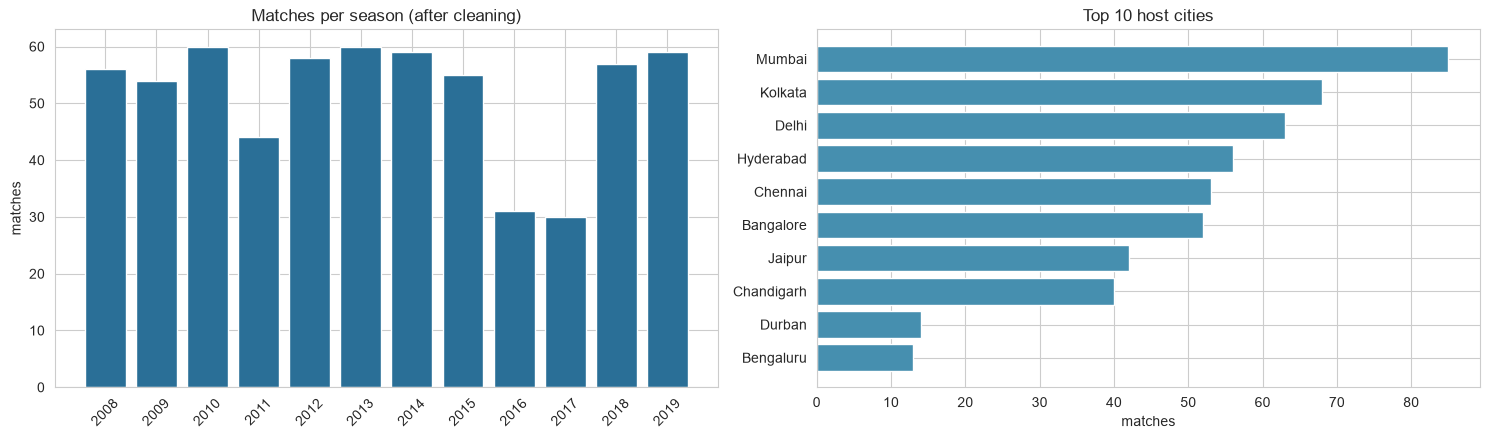

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

season_counts = matches_clean['Season'].value_counts().sort_index()
axes[0].bar(range(len(season_counts)), season_counts.values, color='#2a6f97')
axes[0].set_xticks(range(len(season_counts)))
axes[0].set_xticklabels([s.replace('IPL-', '') for s in season_counts.index], rotation=45)
axes[0].set_title('Matches per season (after cleaning)')
axes[0].set_ylabel('matches')

top_cities = matches_clean['city'].value_counts().head(10)
axes[1].barh(top_cities.index[::-1], top_cities.values[::-1], color='#468faf')
axes[1].set_title('Top 10 host cities')
axes[1].set_xlabel('matches')

plt.tight_layout(); plt.show()

In [ ]:

matches_clean['toss_winner_won'] = matches_clean['toss_winner'] == matches_clean['winner']

print('Toss winner also won the match: {:.2f}%'.format(matches_clean['toss_winner_won'].mean() * 100))
print()
print('Toss decisions taken:')
print(matches_clean['toss_decision'].value_counts())
print()
print('Win rate of the toss winner, split by what they chose to do:')
print((matches_clean.groupby('toss_decision')['toss_winner_won'].mean() * 100).round(2))

Toss winner also won the match: 51.69%

Toss decisions taken:
toss_decision
field    377
bat      246
Name: count, dtype: int64

Win rate of the toss winner, split by what they chose to do:
toss_decision
bat      46.75
field    54.91
Name: toss_winner_won, dtype: float64


In [ ]:

first_innings_total = (deliveries_clean[deliveries_clean['inning'] == 1]
                       .groupby('match_id')['total_runs'].sum()
                       .reset_index().rename(columns={'total_runs': 'target_score'}))

match_info = matches_clean.merge(first_innings_total, left_on='id', right_on='match_id')
match_info = match_info[['match_id', 'city', 'winner', 'target_score', 'Season']]
print('Matches with a first-innings total:', len(match_info))
print('Average target:', round(match_info['target_score'].mean(), 1))

Matches with a first-innings total: 623
Average target: 164.0


## 7. Building the second-innings match-state dataset



In [51]:
second_innings = match_info.merge(deliveries_clean, on='match_id')
second_innings = second_innings[second_innings['inning'] == 2].copy()
second_innings = second_innings.sort_values(['match_id', 'over', 'ball']).reset_index(drop=True)

# --- correct legal-ball counting (this is the fix for the 126-ball bug) ---
second_innings['is_legal_ball'] = ((second_innings['wide_runs'] == 0) &
                                   (second_innings['noball_runs'] == 0)).astype(int)
second_innings['legal_balls_bowled'] = second_innings.groupby('match_id')['is_legal_ball'].cumsum()

second_innings['current_score'] = second_innings.groupby('match_id')['total_runs'].cumsum()
second_innings['runs_left'] = second_innings['target_score'] - second_innings['current_score']
second_innings['balls_left'] = 120 - second_innings['legal_balls_bowled']

# wickets: player_dismissed is missing on non-wicket balls, so notna() IS the wicket flag
second_innings['is_wicket'] = second_innings['player_dismissed'].notna().astype(int)
second_innings['wickets'] = 10 - second_innings.groupby('match_id')['is_wicket'].cumsum()

second_innings['current_run_rate'] = np.where(
    second_innings['legal_balls_bowled'] > 0,
    second_innings['current_score'] * 6 / second_innings['legal_balls_bowled'], 0.0)
second_innings['required_run_rate'] = np.where(
    second_innings['balls_left'] > 0,
    second_innings['runs_left'] * 6 / second_innings['balls_left'], 0.0)

print('Second-innings rows:', len(second_innings))
second_innings[['match_id','over','ball','is_legal_ball','legal_balls_bowled',
                'balls_left','current_score','runs_left','wickets',
                'current_run_rate','required_run_rate']].head(10)

Second-innings rows: 72378


,match_id,over,ball,is_legal_ball,legal_balls_bowled,balls_left,current_score,runs_left,wickets,current_run_rate,required_run_rate
0,1,1,1,1,1,119,1,206,10,6.000000,10.386555
1,1,1,2,1,2,118,1,206,10,3.000000,10.474576
2,1,1,3,1,3,117,1,206,10,2.000000,10.564103
3,1,1,4,1,4,116,3,204,10,4.500000,10.551724
4,1,1,5,1,5,115,7,200,10,8.400000,10.434783
5,1,1,6,1,6,114,11,196,10,11.000000,10.315789
6,1,2,1,1,7,113,11,196,10,9.428571,10.407080
7,1,2,2,1,8,112,11,196,10,8.250000,10.500000
8,1,2,3,1,9,111,12,195,10,8.000000,10.540541
9,1,2,4,1,10,110,12,195,10,7.200000,10.636364


In [53]:
# Proof the fix matters: compare old formula vs correct legal-ball count
second_innings['balls_left_old_formula'] = 126 - (second_innings['over'] * 6 + second_innings['ball'])
disagree = (second_innings['balls_left'] != second_innings['balls_left_old_formula']).sum()
print(f'Rows where the old 126-formula disagrees with the correct count: '
      f'{disagree} ({disagree/len(second_innings)*100:.1f}%)')
print()
print('Example rows where they differ:')
mask = second_innings['balls_left'] != second_innings['balls_left_old_formula']
print(second_innings.loc[mask, ['match_id','over','ball','wide_runs','noball_runs',
                                'balls_left','balls_left_old_formula']].head(8).to_string(index=False))
second_innings = second_innings.drop(columns=['balls_left_old_formula'])

Rows where the old 126-formula disagrees with the correct count: 10706 (14.8%)

Example rows where they differ:
 match_id  over  ball  wide_runs  noball_runs  balls_left  balls_left_old_formula
        1     4     4          1            0          99                      98
        1     4     5          0            0          98                      97
        1     4     6          0            0          97                      96
        1     4     7          0            0          96                      95
        1     5     4          1            0          93                      92
        1     5     5          0            0          92                      91
        1     5     6          0            0          91                      90
        1     5     7          0            0          90                      89


## 8. Target construction


In [56]:
second_innings['result'] = (second_innings['batting_team'] == second_innings['winner']).astype(int)

# The label must be constant within a match - verify
constant = second_innings.groupby('match_id')['result'].nunique().eq(1).all()
print('result is constant within every match:', constant)
print()
print('Row-level class balance:')
print(second_innings['result'].value_counts())
print(second_innings['result'].value_counts(normalize=True).round(4))

result is constant within every match: True

Row-level class balance:
result
1    38056
0    34322
Name: count, dtype: int64
result
1    0.5258
0    0.4742
Name: proportion, dtype: float64


## 9. Momentum features - and why the shift matters


In [ ]:
over_level = (second_innings.groupby(['match_id', 'over'])
              .agg(runs_in_over=('total_runs', 'sum'), wickets_in_over=('is_wicket', 'sum'))
              .reset_index().sort_values(['match_id', 'over']))

over_level['cum_runs'] = over_level.groupby('match_id')['runs_in_over'].cumsum()
over_level['cum_wickets'] = over_level.groupby('match_id')['wickets_in_over'].cumsum()


def completed_window_sum(group, cumulative_column, window):
    up_to_previous_over = group[cumulative_column].shift(1).fillna(0)
    up_to_window_before = group[cumulative_column].shift(1 + window).fillna(0)
    return up_to_previous_over - up_to_window_before


pieces = []
for match_id, group in over_level.groupby('match_id'):
    group = group.copy()
    group['runs_last_over'] = completed_window_sum(group, 'cum_runs', 1)
    group['runs_last_3_overs'] = completed_window_sum(group, 'cum_runs', 3)
    group['runs_last_5_overs'] = completed_window_sum(group, 'cum_runs', 5)
    group['wickets_last_over'] = completed_window_sum(group, 'cum_wickets', 1)
    group['wickets_last_3_overs'] = completed_window_sum(group, 'cum_wickets', 3)
    pieces.append(group)
over_level = pd.concat(pieces, ignore_index=True)

momentum_columns = ['match_id', 'over', 'runs_last_over', 'runs_last_3_overs',
                    'runs_last_5_overs', 'wickets_last_over', 'wickets_last_3_overs']
second_innings = second_innings.merge(over_level[momentum_columns], on=['match_id', 'over'], how='left')
print(second_innings.loc[second_innings['over'] == 1,
      ['runs_last_over','runs_last_3_overs','runs_last_5_overs']].sum())

runs_last_over       0.0
runs_last_3_overs    0.0
runs_last_5_overs    0.0
dtype: float64


## 10. Derived pressure features


In [ ]:
safe_wickets = second_innings['wickets'].replace(0, 1)   
second_innings['score_progress_pct'] = np.where(
    second_innings['target_score'] > 0,
    second_innings['current_score'] / second_innings['target_score'] * 100, 0)
second_innings['runs_left_per_wicket'] = second_innings['runs_left'] / safe_wickets
second_innings['rrr_minus_crr'] = (second_innings['required_run_rate'] -
                                   second_innings['current_run_rate'])
second_innings['pressure_index'] = second_innings['required_run_rate'] / (second_innings['wickets'] + 1)
print(second_innings[['score_progress_pct','runs_left_per_wicket',
                      'rrr_minus_crr','pressure_index']].describe().round(2))

       score_progress_pct  runs_left_per_wicket  rrr_minus_crr  pressure_index
count            72378.00              72378.00       72378.00        72378.00
mean                44.65                 12.89           2.90            1.71
std                 27.69                  9.20          13.07            5.17
min                  0.00                 -7.00         -75.78          -21.00
25%                 21.15                  7.88          -1.00            0.73
50%                 43.26                 12.38           1.58            0.95
75%                 66.84                 16.25           4.48            1.38
max                108.72                161.00         671.95          354.00


In [66]:
FORBIDDEN = ['winner', 'result', 'win_by_runs', 'win_by_wickets', 'player_of_match',
             'dismissal_kind', 'fielder', 'player_dismissed', 'batsman', 'bowler',
             'non_striker', 'is_wicket', 'total_runs', 'batsman_runs', 'extra_runs',
             'wickets_fallen', 'legal_balls_bowled', 'is_legal_ball']

leaked = [c for c in FEATURE_COLS if c in FORBIDDEN]
assert not leaked, f'LEAKAGE: {leaked}'
print('No forbidden column appears in FEATURE_COLS.')
print()
print(f'{len(FEATURE_COLS)} features used:')
print('  categorical:', CAT_COLS)
print('  numerical  :')
for c in NUM_COLS:
    print('     -', c)

No forbidden column appears in FEATURE_COLS.

19 features used:
  categorical: ['batting_team', 'bowling_team', 'city']
  numerical  :
     - target_score
     - current_score
     - runs_left
     - balls_left
     - wickets
     - current_run_rate
     - required_run_rate
     - runs_last_over
     - runs_last_3_overs
     - runs_last_5_overs
     - wickets_last_over
     - wickets_last_3_overs
     - score_progress_pct
     - runs_left_per_wicket
     - rrr_minus_crr
     - pressure_index


In [ ]:

numeric_corr = second_innings[NUM_COLS + ['result']].corr()['result'].drop('result')
print('Correlation of each numeric feature with the target:')
print(numeric_corr.sort_values(key=abs, ascending=False).round(3))
print()
print('Max absolute correlation:', round(numeric_corr.abs().max(), 3))

Correlation of each numeric feature with the target:
target_score           -0.406
runs_left_per_wicket   -0.394
wickets                 0.325
rrr_minus_crr          -0.272
required_run_rate      -0.254
runs_left              -0.250
wickets_last_3_overs   -0.244
pressure_index         -0.179
wickets_last_over      -0.153
current_run_rate        0.127
score_progress_pct      0.125
runs_last_3_overs       0.073
runs_last_5_overs       0.066
runs_last_over          0.066
balls_left              0.053
current_score           0.014
Name: result, dtype: float64

Max absolute correlation: 0.406


## 12. Finalising the modelling table

In [ ]:

before = len(second_innings)
model_df = second_innings[second_innings['balls_left'] != 0].copy()
print(f'Dropped {before - len(model_df)} rows where balls_left == 0 (innings complete)')
print('Super-over rows in this table:', int(model_df['is_super_over'].sum()))
model_df = model_df[['match_id', 'Season'] + FEATURE_COLS + ['result']].dropna().reset_index(drop=True)
print()
print('Final modelling dataset:', model_df.shape)
print('Missing values remaining:', model_df.isna().sum().sum())
print('Matches represented:', model_df['match_id'].nunique())
model_df.head()

Dropped 236 rows where balls_left == 0 (innings complete)
Super-over rows in this table: 0

Final modelling dataset: (72142, 22)
Missing values remaining: 0
Matches represented: 623


,match_id,Season,batting_team,bowling_team,city,target_score,current_score,runs_left,balls_left,wickets,current_run_rate,required_run_rate,runs_last_over,runs_last_3_overs,runs_last_5_overs,wickets_last_over,wickets_last_3_overs,score_progress_pct,runs_left_per_wicket,rrr_minus_crr,pressure_index,result
0,1,IPL-2017,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,1,206,119,10,6.0,10.386555,0.0,0.0,0.0,0.0,0.0,0.483092,20.6,4.386555,0.944232,0
1,1,IPL-2017,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,1,206,118,10,3.0,10.474576,0.0,0.0,0.0,0.0,0.0,0.483092,20.6,7.474576,0.952234,0
2,1,IPL-2017,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,1,206,117,10,2.0,10.564103,0.0,0.0,0.0,0.0,0.0,0.483092,20.6,8.564103,0.960373,0
3,1,IPL-2017,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,3,204,116,10,4.5,10.551724,0.0,0.0,0.0,0.0,0.0,1.449275,20.4,6.051724,0.959248,0
4,1,IPL-2017,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,7,200,115,10,8.4,10.434783,0.0,0.0,0.0,0.0,0.0,3.381643,20.0,2.034783,0.948617,0


## 13. Cricket insights from the match-state data


In [75]:
match_level = model_df.groupby('match_id').agg(
    result=('result', 'first'), target_score=('target_score', 'first')).reset_index()

print('Chasing team win rate across {} matches: {:.2f}%'.format(
    len(match_level), match_level['result'].mean() * 100))

Chasing team win rate across 623 matches: 54.25%


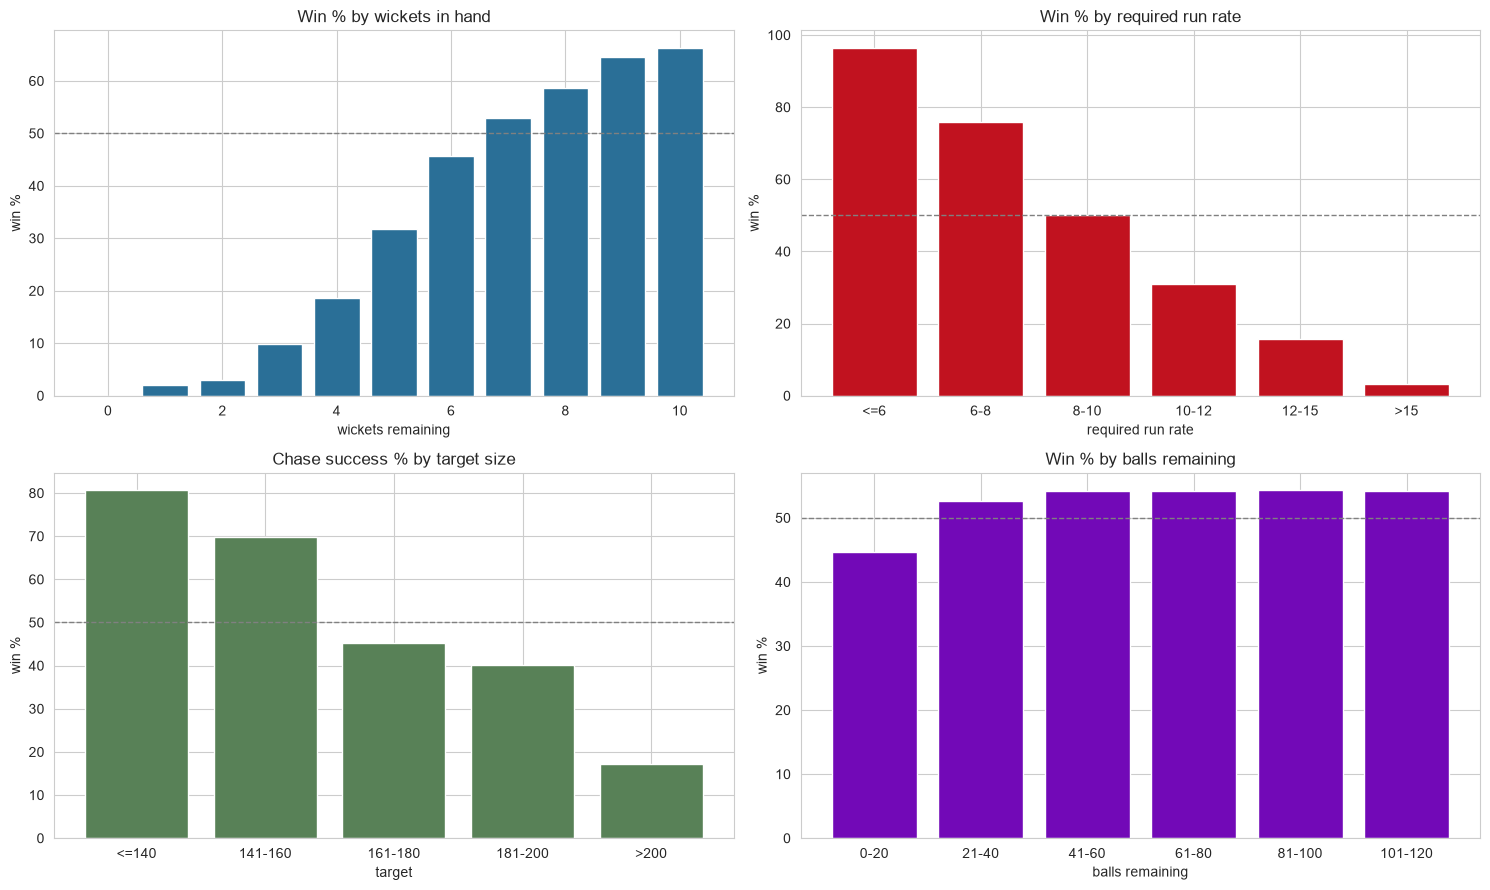

Win % by wickets in hand:
wickets
0      0.00
1      2.09
2      3.06
3      9.91
4     18.66
5     31.85
6     45.69
7     52.99
8     58.70
9     64.47
10    66.30
Name: result, dtype: float64

Win % by required run rate:
required_run_rate
<=6      96.45
6-8      76.01
8-10     50.23
10-12    30.94
12-15    15.80
>15       3.21
Name: result, dtype: float64

Chase success % by target:
target_score
<=140      80.62
141-160    69.72
161-180    45.18
181-200    40.16
>200       17.19
Name: result, dtype: float64

Win % by balls remaining:
balls_left
0-20       44.60
21-40      52.70
41-60      54.19
61-80      54.20
81-100     54.29
101-120    54.26
Name: result, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
wk = model_df.groupby('wickets')['result'].mean() * 100
axes[0, 0].bar(wk.index, wk.values, color='#2a6f97')
axes[0, 0].set_title('Win % by wickets in hand')
axes[0, 0].set_xlabel('wickets remaining'); axes[0, 0].set_ylabel('win %')
axes[0, 0].axhline(50, color='grey', ls='--', lw=1)
rrr_bucket = pd.cut(model_df['required_run_rate'], [-0.01, 6, 8, 10, 12, 15, 1000],
                    labels=['<=6', '6-8', '8-10', '10-12', '12-15', '>15'])
rr = model_df.groupby(rrr_bucket, observed=True)['result'].mean() * 100
axes[0, 1].bar(rr.index.astype(str), rr.values, color='#c1121f')
axes[0, 1].set_title('Win % by required run rate')
axes[0, 1].set_xlabel('required run rate'); axes[0, 1].set_ylabel('win %')
axes[0, 1].axhline(50, color='grey', ls='--', lw=1)

tgt_bucket = pd.cut(match_level['target_score'], [0, 140, 160, 180, 200, 300],
                    labels=['<=140', '141-160', '161-180', '181-200', '>200'])
tg = match_level.groupby(tgt_bucket, observed=True)['result'].mean() * 100
axes[1, 0].bar(tg.index.astype(str), tg.values, color='#588157')
axes[1, 0].set_title('Chase success % by target size')
axes[1, 0].set_xlabel('target'); axes[1, 0].set_ylabel('win %')
axes[1, 0].axhline(50, color='grey', ls='--', lw=1)

bl_bucket = pd.cut(model_df['balls_left'], [-1, 20, 40, 60, 80, 100, 120],
                   labels=['0-20', '21-40', '41-60', '61-80', '81-100', '101-120'])
bl = model_df.groupby(bl_bucket, observed=True)['result'].mean() * 100
axes[1, 1].bar(bl.index.astype(str), bl.values, color='#7209b7')
axes[1, 1].set_title('Win % by balls remaining')
axes[1, 1].set_xlabel('balls remaining'); axes[1, 1].set_ylabel('win %')
axes[1, 1].axhline(50, color='grey', ls='--', lw=1)

plt.tight_layout(); plt.show()

print('Win % by wickets in hand:'); print(wk.round(2))
print(); print('Win % by required run rate:'); print(rr.round(2))
print(); print('Chase success % by target:'); print(tg.round(2))
print(); print('Win % by balls remaining:'); print(bl.round(2))

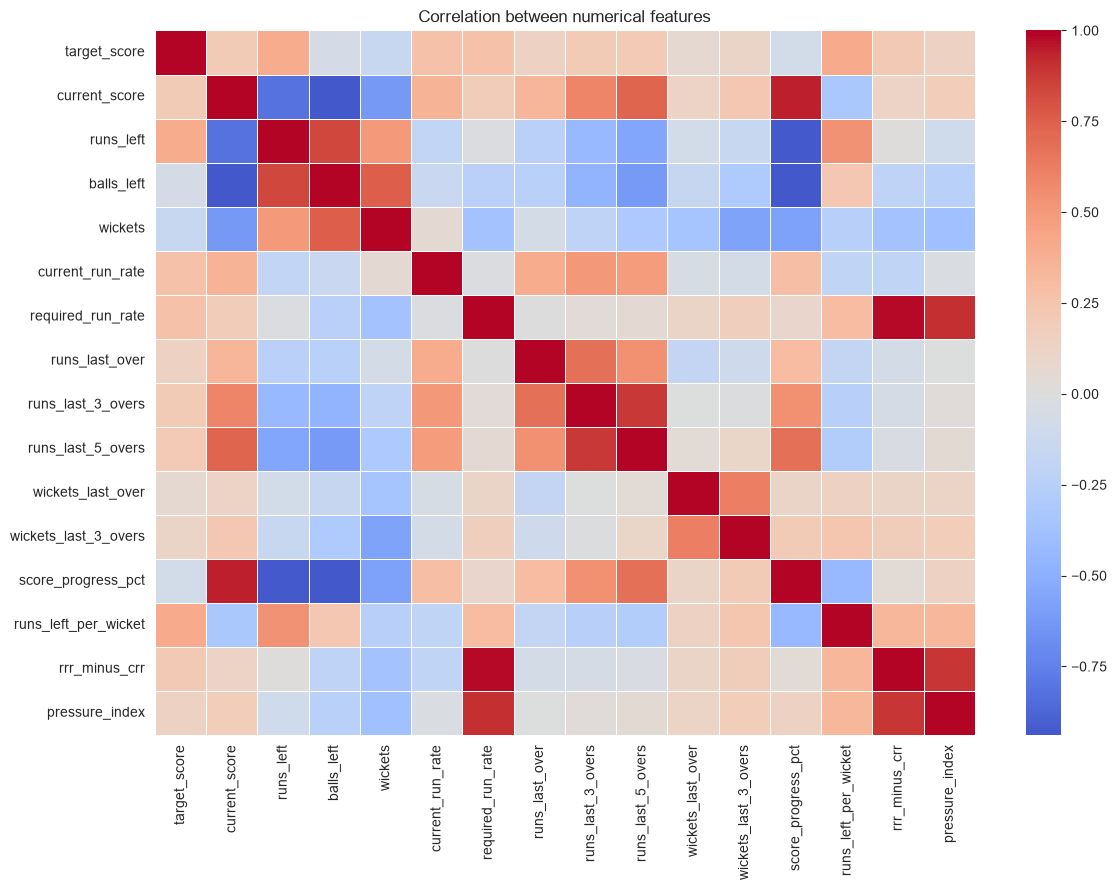

In [80]:
# Correlation heatmap of the numeric features
plt.figure(figsize=(12, 9))
sns.heatmap(model_df[NUM_COLS].corr(), cmap='coolwarm', center=0,
            annot=False, linewidths=0.4)
plt.title('Correlation between numerical features')
plt.tight_layout(); plt.show()

## 14. Feature redundancy check

Before modelling, I check whether any engineered feature is just another feature in
disguise. Adding a rescaled copy of a column is feature-count padding, not feature
engineering.

In [83]:
corr = model_df[NUM_COLS].corr().abs()
redundant_pairs = []
for i in range(len(NUM_COLS)):
    for j in range(i + 1, len(NUM_COLS)):
        if corr.iloc[i, j] > 0.85:
            redundant_pairs.append((NUM_COLS[i], NUM_COLS[j], round(corr.iloc[i, j], 3)))

print('Feature pairs with |correlation| > 0.85:')
for a, b, r in sorted(redundant_pairs, key=lambda x: -x[2]):
    print(f'  {r:.3f}   {a}  <->  {b}')

Feature pairs with |correlation| > 0.85:
  0.983   required_run_rate  <->  rrr_minus_crr
  0.947   current_score  <->  score_progress_pct
  0.939   current_score  <->  balls_left
  0.939   balls_left  <->  score_progress_pct
  0.931   runs_left  <->  score_progress_pct
  0.902   required_run_rate  <->  pressure_index
  0.888   rrr_minus_crr  <->  pressure_index
  0.884   runs_last_3_overs  <->  runs_last_5_overs


## 15. Outlier and distribution analysis

The rule here: **a cricket extreme is not a data error.** I only treat a value if I can
argue it is either impossible or actively harmful to the model.

In [87]:
outlier_cols = ['runs_left', 'balls_left', 'wickets', 'target_score', 'current_score',
                'current_run_rate', 'required_run_rate', 'pressure_index']

print(model_df[outlier_cols].describe().T.round(2))
print()
print('Skewness:')
print(model_df[outlier_cols].skew().round(2))

                     count    mean    std   min     25%     50%     75%    max
runs_left          72142.0   92.49  49.91 -15.0   53.00   92.00  130.00  249.0
balls_left         72142.0   63.00  33.26  -1.0   35.00   64.00   92.00  120.0
wickets            72142.0    7.55   2.12   0.0    6.00    8.00    9.00   10.0
target_score       72142.0  165.55  29.23  67.0  146.00  165.00  185.00  250.0
current_score      72142.0   73.06  46.69   0.0   34.00   70.00  108.00  222.0
current_run_rate   72142.0    7.49   2.37   0.0    6.29    7.50    8.72   84.0
required_run_rate  72142.0   10.42  12.80 -66.0    7.12    8.85   10.85  678.0
pressure_index     72142.0    1.71   5.17 -21.0    0.73    0.95    1.38  354.0

Skewness:
runs_left             0.14
balls_left           -0.06
wickets              -0.89
target_score         -0.10
current_score         0.33
current_run_rate      1.52
required_run_rate    16.83
pressure_index       23.34
dtype: float64


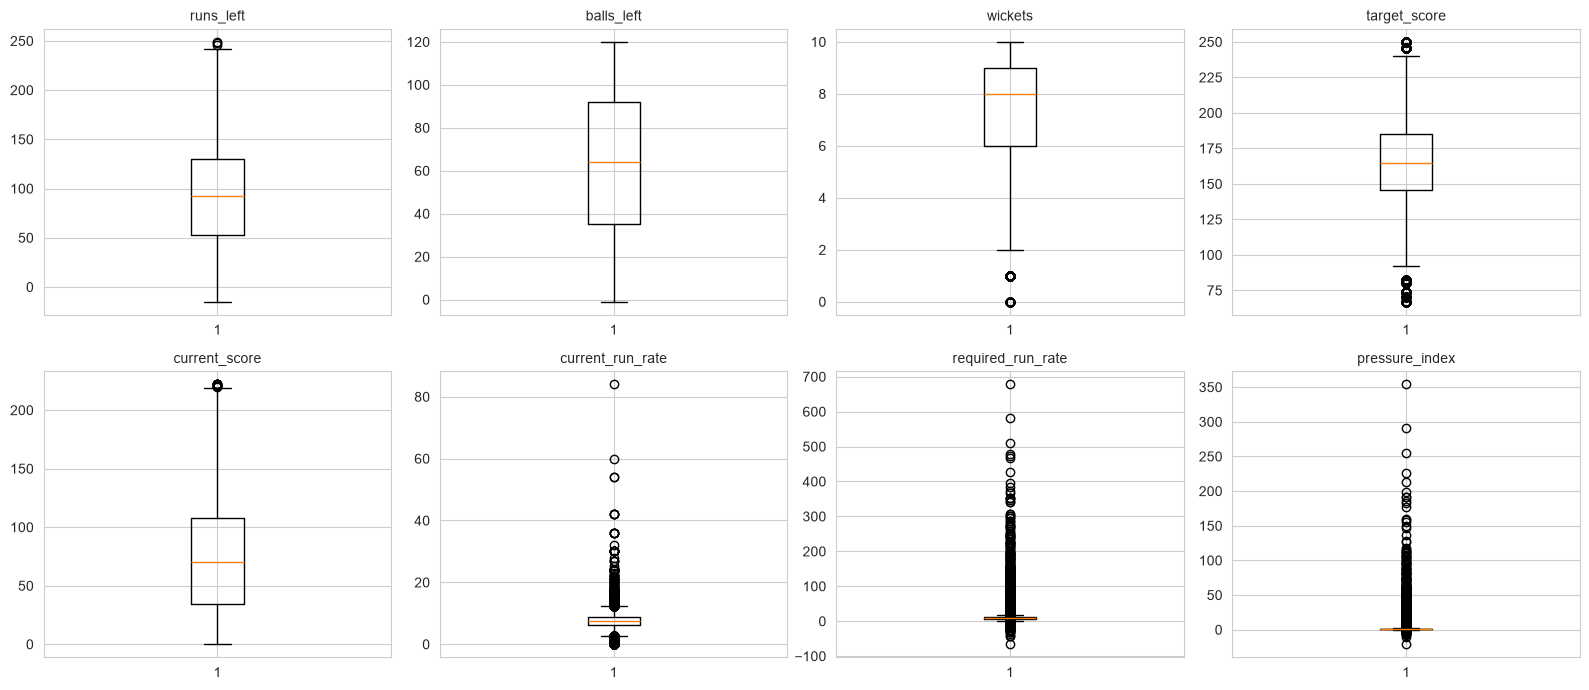

In [89]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), outlier_cols):
    ax.boxplot(model_df[col].values, vert=True)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

In [91]:
# IQR analysis on the two most skewed features
for col in ['required_run_rate', 'target_score']:
    q1, q3 = model_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = ((model_df[col] < low) | (model_df[col] > high)).sum()
    print(f'{col:20s} IQR bounds [{low:7.2f}, {high:7.2f}]  '
          f'flagged {flagged:5d} ({flagged/len(model_df)*100:.2f}%)  max {model_df[col].max():.1f}')

print()
print('Percentiles of required_run_rate:')
print(model_df['required_run_rate'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0]).round(2))

required_run_rate    IQR bounds [   1.52,   16.45]  flagged  6158 (8.54%)  max 678.0
target_score         IQR bounds [  87.50,  243.50]  flagged   785 (1.09%)  max 250.0

Percentiles of required_run_rate:
0.500      8.85
0.900     14.38
0.950     18.67
0.990     48.00
0.999    188.58
1.000    678.00
Name: required_run_rate, dtype: float64


In [93]:
# Are the extreme RRR rows data errors, or real cricket?
extreme = model_df[model_df['required_run_rate'] > 36]
print('Rows needing more than 36 an over (a six off every remaining ball):', len(extreme))
print()
print('What actually happened in those situations:')
print(extreme['result'].value_counts(normalize=True).round(4))
print()
print(extreme[['runs_left', 'balls_left', 'required_run_rate', 'result']].head(6).to_string(index=False))

Rows needing more than 36 an over (a six off every remaining ball): 1064

What actually happened in those situations:
result
0    0.9981
1    0.0019
Name: proportion, dtype: float64

 runs_left  balls_left  required_run_rate  result
        43           7          36.857143       0
        42           6          42.000000       0
        42           5          50.400000       0
        41           4          61.500000       0
        35           3          70.000000       0
        35           2         105.000000       0


In [97]:
train_seasons = ['IPL-2008','IPL-2009','IPL-2010','IPL-2011','IPL-2012',
                 'IPL-2013','IPL-2014','IPL-2015','IPL-2016']
val_seasons   = ['IPL-2017']
test_seasons  = ['IPL-2018', 'IPL-2019']

train_df = model_df[model_df['Season'].isin(train_seasons)].copy()
val_df   = model_df[model_df['Season'].isin(val_seasons)].copy()
test_df  = model_df[model_df['Season'].isin(test_seasons)].copy()

for name, part in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f'{name:11s} {part["match_id"].nunique():4d} matches   {len(part):6d} rows   '
          f'chase win rate {part.groupby("match_id")["result"].first().mean():.3f}')

# Prove no match leaks across the splits
assert not (set(train_df['match_id']) & set(val_df['match_id']))
assert not (set(train_df['match_id']) & set(test_df['match_id']))
assert not (set(val_df['match_id']) & set(test_df['match_id']))
print()
print('Verified: no match_id appears in more than one split.')

Train        477 matches    55194 rows   chase win rate 0.539
Validation    30 matches     3309 rows   chase win rate 0.467
Test         116 matches    13639 rows   chase win rate 0.578

Verified: no match_id appears in more than one split.


In [99]:
X_train, y_train = train_df[FEATURE_COLS], train_df['result']
X_val,   y_val   = val_df[FEATURE_COLS],   val_df['result']
X_test,  y_test  = test_df[FEATURE_COLS],  test_df['result']
groups_train = train_df['match_id']      # used for group-aware cross-validation

print('X_train', X_train.shape, '| X_val', X_val.shape, '| X_test', X_test.shape)

X_train (55194, 19) | X_val (3309, 19) | X_test (13639, 19)


## 17. Class imbalance check

Check first, act only if needed. Applying SMOTE reflexively to a balanced target adds
synthetic rows and distorts the probabilities - which are the whole product here.

In [102]:
print('Row-level target distribution (training set):')
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

Row-level target distribution (training set):
result
1    28832
0    26362
Name: count, dtype: int64
result
1    0.5224
0    0.4776
Name: proportion, dtype: float64


In [ ]:
import inspect
print(inspect.getsource(cricket_utils.build_preprocessor))
print(inspect.getsource(cricket_utils.clip_extreme_rates))

def build_preprocessor(scale=False):
    """One-hot encode the team/city columns and clip the extreme rate columns.

    `scale=True` adds StandardScaler, which matters for Logistic Regression and
    SVC but is unnecessary for tree-based models.
    """
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

    numeric_steps = [('clip', FunctionTransformer(clip_extreme_rates,
                                                  feature_names_out='one-to-one'))]
    if scale:
        numeric_steps.append(('scale', StandardScaler()))

    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), CAT_COLS),
        ('num', Pipeline(numeric_steps), NUM_COLS),
    ])

def clip_extreme_rates(X):
    """Cap mathematically extreme rate features. Used inside the sklearn pipeline."""
    X = pd.DataFrame(X, columns=NUM_COLS).copy()
  

In [ ]:

demo = build_preprocessor(scale=False).fit(X_train)
print('Feature count after one-hot encoding:', len(demo.get_feature_names_out()))
print()
print('First 12 output feature names:')
for n in demo.get_feature_names_out()[:12]:
    print('  ', n)

Feature count after one-hot encoding: 56

First 12 output feature names:
   cat__batting_team_Delhi Capitals
   cat__batting_team_Kings XI Punjab
   cat__batting_team_Kolkata Knight Riders
   cat__batting_team_Mumbai Indians
   cat__batting_team_Rajasthan Royals
   cat__batting_team_Royal Challengers Bangalore
   cat__batting_team_Sunrisers Hyderabad
   cat__bowling_team_Delhi Capitals
   cat__bowling_team_Kings XI Punjab
   cat__bowling_team_Kolkata Knight Riders
   cat__bowling_team_Mumbai Indians
   cat__bowling_team_Rajasthan Royals


## 19. Model comparison

Six candidates. Because the deliverable is a probability, I record **log loss** and
**Brier score** alongside the usual classification metrics.

- higher is better: Accuracy, Precision, Recall, F1, ROC-AUC
- **lower is better: Log Loss, Brier Score**

*Note on SVC:* an RBF SVC on 55,000 rows is O(n²) and takes far too long to be
practical here, so it is fitted on a random 8,000-row sample of the training set. That
is a genuine limitation of the model for this data size, and I report it rather than
hiding it.

In [111]:
def evaluate_model(pipe, X, y, threshold=0.5):
    """All the metrics we care about, computed from predicted probabilities."""
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall':    recall_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, proba),
        'LogLoss':   log_loss(y, proba),
        'Brier':     brier_score_loss(y, proba),
    }

In [ ]:

baseline_prob = y_train.mean()
baseline_proba = np.full(len(y_test), baseline_prob)
print(f'Baseline (always predict {baseline_prob:.3f}):')
print(f'  Accuracy : {accuracy_score(y_test, (baseline_proba >= 0.5).astype(int)):.4f}')
print(f'  LogLoss  : {log_loss(y_test, baseline_proba):.4f}')
print(f'  Brier    : {brier_score_loss(y_test, baseline_proba):.4f}')

Baseline (always predict 0.522):
  Accuracy : 0.5676
  LogLoss  : 0.6881
  Brier    : 0.2475


In [ ]:

models_to_compare = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, solver='liblinear'), True),
    'Gaussian Naive Bayes': (GaussianNB(), False),
    'SVC (RBF)': (SVC(probability=True, kernel='rbf', C=1.0, cache_size=500,
                      random_state=RANDOM_STATE), True),
    'Gradient Boosting': (GradientBoostingClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        min_samples_leaf=200, subsample=0.8, random_state=RANDOM_STATE), False),
    'Random Forest': (RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=20,
        random_state=RANDOM_STATE, n_jobs=-1), False),
    'XGBoost': (XGBClassifier(
        n_estimators=600, max_depth=3, learning_rate=0.02, subsample=0.7,
        colsample_bytree=0.7, min_child_weight=10, reg_lambda=20,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1), False),
}

fitted_models = {}
val_results, test_results = {}, {}

for name, (classifier, needs_scaling) in models_to_compare.items():
    pipe = Pipeline([
        ('preprocess', build_preprocessor(scale=needs_scaling)),
        ('model', classifier),
    ])

    if name == 'SVC (RBF)':
        sample_index = X_train.sample(n=8000, random_state=RANDOM_STATE).index
        pipe.fit(X_train.loc[sample_index], y_train.loc[sample_index])
    else:
        pipe.fit(X_train, y_train)

    fitted_models[name] = pipe
    val_results[name] = evaluate_model(pipe, X_val, y_val)
    test_results[name] = evaluate_model(pipe, X_test, y_test)
    print(f'{name} trained')

Logistic Regression trained
Gaussian Naive Bayes trained
SVC (RBF) trained
Gradient Boosting trained
Random Forest trained
XGBoost trained


In [116]:
validation_table = pd.DataFrame(val_results).T.sort_values('LogLoss')
print('VALIDATION - IPL-2017 (30 matches)')
validation_table.round(4)

VALIDATION - IPL-2017 (30 matches)


,Accuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Brier
Random Forest,0.7749,0.7173,0.8065,0.7593,0.8956,0.4044,0.1347
XGBoost,0.7564,0.6811,0.8401,0.7523,0.8834,0.4273,0.1450
SVC (RBF),0.8039,0.7475,0.8373,0.7899,0.8969,0.4275,0.1400
Logistic Regression,0.7652,0.7117,0.7845,0.7463,0.8639,0.4510,0.1554
Gradient Boosting,0.7138,0.6344,0.8264,0.7177,0.8589,0.4821,0.1677
Gaussian Naive Bayes,0.6760,0.5825,0.9327,0.7172,0.8221,1.6288,0.2904


In [117]:
comparison_table = pd.DataFrame(test_results).T.sort_values('LogLoss')
print('TEST - IPL-2018 + IPL-2019 (116 unseen matches)')
comparison_table.round(4)

TEST - IPL-2018 + IPL-2019 (116 unseen matches)


,Accuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Brier
Random Forest,0.7102,0.7953,0.6593,0.7209,0.8172,0.5471,0.1861
XGBoost,0.7071,0.7817,0.6715,0.7224,0.8097,0.5601,0.1906
Logistic Regression,0.7129,0.7897,0.6736,0.7270,0.8158,0.5621,0.1896
Gradient Boosting,0.6961,0.7681,0.6656,0.7132,0.7961,0.5980,0.2028
SVC (RBF),0.6955,0.7576,0.6817,0.7177,0.7819,0.6760,0.2147
Gaussian Naive Bayes,0.6896,0.7059,0.7767,0.7396,0.7201,2.3849,0.2813


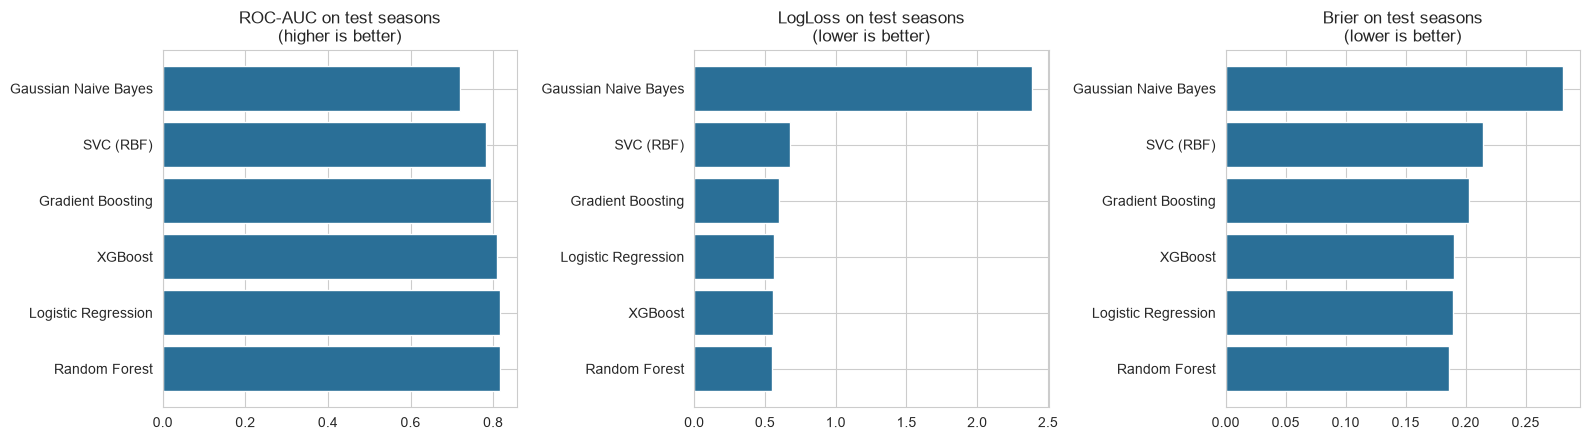

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric, better in zip(axes, ['ROC-AUC', 'LogLoss', 'Brier'],
                              ['higher is better', 'lower is better', 'lower is better']):
    ordered = comparison_table[metric].sort_values(ascending=(metric != 'ROC-AUC'))
    ax.barh(ordered.index, ordered.values, color='#2a6f97')
    ax.set_title(f'{metric} on test seasons\n({better})')
plt.tight_layout(); plt.show()

## 20. Hyperparameter tuning



In [ ]:

RUN_TUNING = True

if RUN_TUNING:
    xgb_grid = {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [2, 3, 4],
        'model__learning_rate': [0.02, 0.05, 0.1],
        'model__subsample': [0.7, 0.9],
        'model__colsample_bytree': [0.7, 0.9],
        'model__min_child_weight': [10, 50, 200],
        'model__reg_lambda': [1, 5, 20],
    }
    xgb_pipe = Pipeline([
        ('preprocess', build_preprocessor(scale=False)),
        ('model', XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    search = RandomizedSearchCV(xgb_pipe, xgb_grid, n_iter=12, scoring='neg_log_loss',
                                cv=GroupKFold(n_splits=4), random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train, groups=groups_train)

    print('Best CV log loss:', round(-search.best_score_, 4))
    print('Best parameters:')
    for k, v in search.best_params_.items():
        print(f'   {k}: {v}')

    tuned_val_proba = search.best_estimator_.predict_proba(X_val)[:, 1]
    print()
    print('Tuned XGBoost on validation -> LogLoss {:.4f} | AUC {:.4f}'.format(
        log_loss(y_val, tuned_val_proba), roc_auc_score(y_val, tuned_val_proba)))

Best CV log loss: 0.4412
Best parameters:
   model__subsample: 0.9
   model__reg_lambda: 1
   model__n_estimators: 600
   model__min_child_weight: 200
   model__max_depth: 2
   model__learning_rate: 0.02
   model__colsample_bytree: 0.9

Tuned XGBoost on validation -> LogLoss 0.4237 | AUC 0.8808


In [126]:
# Random Forest and Gradient Boosting: a few explicit candidates, scored on the
# validation season. Small deliberate search rather than a huge grid.
rf_candidates = [
    dict(n_estimators=200, max_depth=8,    min_samples_leaf=50),
    dict(n_estimators=200, max_depth=12,   min_samples_leaf=50),
    dict(n_estimators=200, max_depth=16,   min_samples_leaf=100),
    dict(n_estimators=200, max_depth=None, min_samples_leaf=20),
]

tuning_rows = []
for params in rf_candidates:
    pipe = Pipeline([('preprocess', build_preprocessor(scale=False)),
                     ('model', RandomForestClassifier(random_state=RANDOM_STATE,
                                                      n_jobs=-1, **params))])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_val)[:, 1]
    tuning_rows.append({**params,
                        'val_logloss': log_loss(y_val, proba),
                        'val_auc': roc_auc_score(y_val, proba)})

rf_tuning = pd.DataFrame(tuning_rows).sort_values('val_logloss')
print('Random Forest candidates (scored on IPL-2017 validation):')
rf_tuning.round(4)

Random Forest candidates (scored on IPL-2017 validation):


,n_estimators,max_depth,min_samples_leaf,val_logloss,val_auc
3,200,NaN,20,0.4044,0.8956
1,200,12.0,50,0.4138,0.8876
2,200,16.0,100,0.4228,0.8812
0,200,8.0,50,0.4305,0.8791



## 21. Re-evaluation: are these numbers trustworthy?



In [128]:
# Why is validation so much better than test? Break the test set down by season.
best_so_far = fitted_models['Random Forest']

for season, group in test_df.groupby('Season'):
    proba = best_so_far.predict_proba(group[FEATURE_COLS])[:, 1]
    print(f'{season}: {group["match_id"].nunique():3d} matches | '
          f'AUC {roc_auc_score(group["result"], proba):.4f} | '
          f'LogLoss {log_loss(group["result"], proba):.4f}')

print()
season_summary = model_df.groupby('Season').apply(
    lambda g: pd.Series({
        'matches': g['match_id'].nunique(),
        'chase_win_rate': round(g.groupby('match_id')['result'].first().mean(), 3),
        'avg_target': round(g.groupby('match_id')['target_score'].first().mean(), 1),
    }), include_groups=False)
print('Season-by-season context:')
print(season_summary)

IPL-2018:  57 matches | AUC 0.7739 | LogLoss 0.6136
IPL-2019:  59 matches | AUC 0.8552 | LogLoss 0.4827

Season-by-season context:
          matches  chase_win_rate  avg_target
Season                                       
IPL-2008     56.0           0.607       161.9
IPL-2009     54.0           0.519       150.3
IPL-2010     60.0           0.467       164.8
IPL-2011     44.0           0.455       163.0
IPL-2012     58.0           0.603       158.1
IPL-2013     60.0           0.567       154.5
IPL-2014     59.0           0.610       163.4
IPL-2015     55.0           0.436       165.7
IPL-2016     31.0           0.581       166.6
IPL-2017     30.0           0.467       166.1
IPL-2018     57.0           0.544       179.5
IPL-2019     59.0           0.610       175.4


## 22. Probability calibration


In [131]:
from sklearn.frozen import FrozenEstimator   # sklearn >= 1.6

calibration_rows = {}
for name in ['Random Forest', 'XGBoost', 'Logistic Regression', 'Gradient Boosting']:
    base = fitted_models[name]

    raw = base.predict_proba(X_test)[:, 1]
    calibration_rows[f'{name} | raw'] = {
        'ROC-AUC': roc_auc_score(y_test, raw),
        'LogLoss': log_loss(y_test, raw),
        'Brier': brier_score_loss(y_test, raw)}

    for method in ['sigmoid', 'isotonic']:
        calibrated = CalibratedClassifierCV(FrozenEstimator(base), method=method)
        calibrated.fit(X_val, y_val)          # fitted on validation only
        proba = calibrated.predict_proba(X_test)[:, 1]
        calibration_rows[f'{name} | {method}'] = {
            'ROC-AUC': roc_auc_score(y_test, proba),
            'LogLoss': log_loss(y_test, proba),
            'Brier': brier_score_loss(y_test, proba)}

calibration_table = pd.DataFrame(calibration_rows).T.sort_values('LogLoss')
calibration_table.round(4)

,ROC-AUC,LogLoss,Brier
Random Forest | raw,0.8172,0.5471,0.1861
XGBoost | raw,0.8097,0.5601,0.1906
Logistic Regression | raw,0.8158,0.5621,0.1896
Logistic Regression | sigmoid,0.8158,0.5947,0.2038
Gradient Boosting | raw,0.7961,0.5980,0.2028
Random Forest | sigmoid,0.8172,0.6399,0.2138
Gradient Boosting | sigmoid,0.7961,0.6485,0.2236
XGBoost | sigmoid,0.8097,0.6542,0.2194
Logistic Regression | isotonic,0.8122,1.0448,0.2058
Gradient Boosting | isotonic,0.7864,1.1816,0.2163


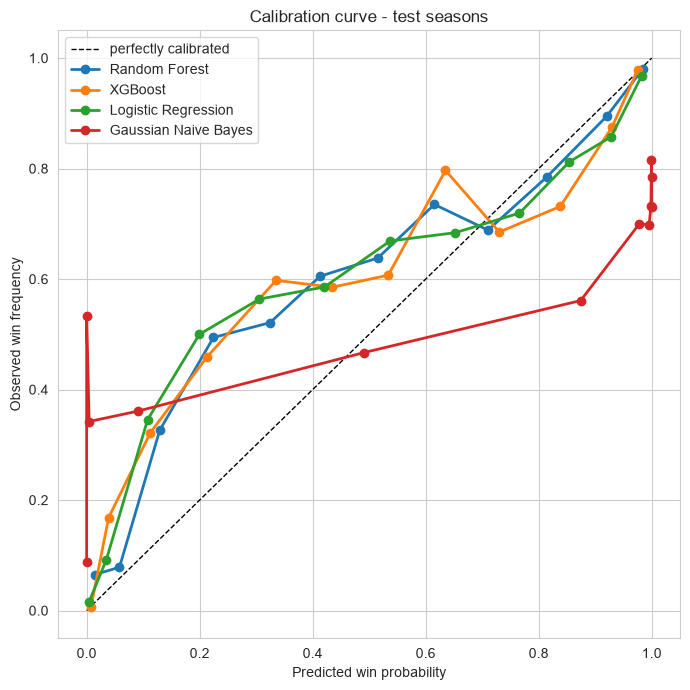

In [ ]:

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='perfectly calibrated')

for name in ['Random Forest', 'XGBoost', 'Logistic Regression', 'Gaussian Naive Bayes']:
    proba = fitted_models[name].predict_proba(X_test)[:, 1]
    true_frac, pred_frac = calibration_curve(y_test, proba, n_bins=12, strategy='quantile')
    plt.plot(pred_frac, true_frac, marker='o', lw=2, label=name)

plt.xlabel('Predicted win probability')
plt.ylabel('Observed win frequency')
plt.title('Calibration curve - test seasons')
plt.legend(); plt.tight_layout(); plt.show()

## 23. Final model selection


In [135]:
selection_view = comparison_table[['ROC-AUC', 'LogLoss', 'Brier', 'Accuracy', 'F1']].copy()
selection_view['rank_auc'] = selection_view['ROC-AUC'].rank(ascending=False)
selection_view['rank_logloss'] = selection_view['LogLoss'].rank()
selection_view['rank_brier'] = selection_view['Brier'].rank()
selection_view['avg_rank'] = selection_view[['rank_auc','rank_logloss','rank_brier']].mean(axis=1)
selection_view.sort_values('avg_rank').round(4)

,ROC-AUC,LogLoss,Brier,Accuracy,F1,rank_auc,rank_logloss,rank_brier,avg_rank
Random Forest,0.8172,0.5471,0.1861,0.7102,0.7209,1.0,1.0,1.0,1.0000
Logistic Regression,0.8158,0.5621,0.1896,0.7129,0.7270,2.0,3.0,2.0,2.3333
XGBoost,0.8097,0.5601,0.1906,0.7071,0.7224,3.0,2.0,3.0,2.6667
Gradient Boosting,0.7961,0.5980,0.2028,0.6961,0.7132,4.0,4.0,4.0,4.0000
SVC (RBF),0.7819,0.6760,0.2147,0.6955,0.7177,5.0,5.0,5.0,5.0000
Gaussian Naive Bayes,0.7201,2.3849,0.2813,0.6896,0.7396,6.0,6.0,6.0,6.0000


In [142]:
BEST_MODEL_NAME = 'Logistic Regression'
best_model = fitted_models[BEST_MODEL_NAME]
test_proba = best_model.predict_proba(X_test)[:, 1]
print('Selected:', BEST_MODEL_NAME)

Selected: Logistic Regression


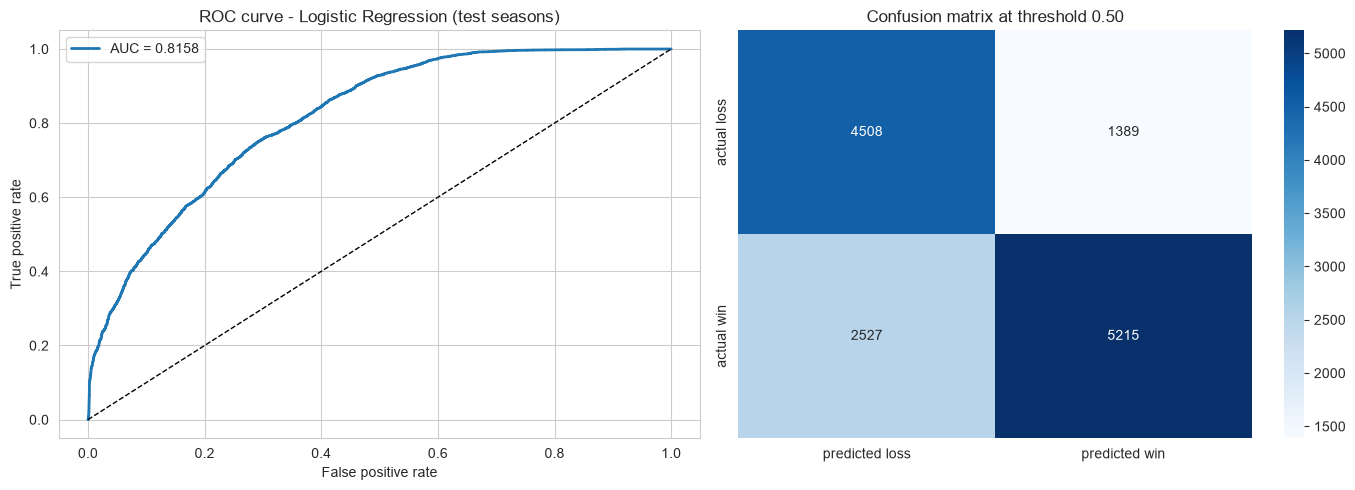

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc_score(y_test, test_proba):.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title(f'ROC curve - {BEST_MODEL_NAME} (test seasons)')
axes[0].legend()

cm = confusion_matrix(y_test, (test_proba >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['predicted loss', 'predicted win'],
            yticklabels=['actual loss', 'actual win'])
axes[1].set_title('Confusion matrix at threshold 0.50')

plt.tight_layout(); plt.show()

## 24. Threshold analysis


In [181]:
threshold_rows = []
for t in np.arange(0.20, 0.81, 0.05):
    val_pred = (best_model.predict_proba(X_val)[:, 1] >= t).astype(int)
    test_pred = (test_proba >= t).astype(int)
    threshold_rows.append({
        'threshold': round(t, 2),
        'val_f1': f1_score(y_val, val_pred),
        'val_accuracy': accuracy_score(y_val, val_pred),
        'test_f1': f1_score(y_test, test_pred),
        'test_precision': precision_score(y_test, test_pred),
        'test_recall': recall_score(y_test, test_pred),
        'test_accuracy': accuracy_score(y_test, test_pred),
    })

threshold_table = pd.DataFrame(threshold_rows)
BEST_THRESHOLD = threshold_table.loc[threshold_table['val_f1'].idxmax(), 'threshold']
print('Threshold chosen on validation:', BEST_THRESHOLD)
threshold_table.round(4)

Threshold chosen on validation: 0.5


,threshold,val_f1,val_accuracy,test_f1,test_precision,test_recall,test_accuracy
0,0.20,0.7215,0.6706,0.7987,0.7198,0.8969,0.7433
1,0.25,0.7282,0.6911,0.7917,0.7324,0.8614,0.7426
2,0.30,0.7332,0.7090,0.7785,0.7409,0.8201,0.7351
3,0.35,0.7350,0.7217,0.7687,0.7528,0.7853,0.7317
4,0.40,0.7339,0.7298,0.7612,0.7699,0.7528,0.7319
5,0.45,0.7411,0.7504,0.7468,0.7798,0.7165,0.7242
6,0.50,0.7463,0.7652,0.7270,0.7897,0.6736,0.7129
7,0.55,0.7458,0.7697,0.7042,0.7972,0.6306,0.6992
8,0.60,0.7352,0.7682,0.6823,0.8097,0.5895,0.6883
9,0.65,0.7218,0.7652,0.6577,0.8233,0.5475,0.6764


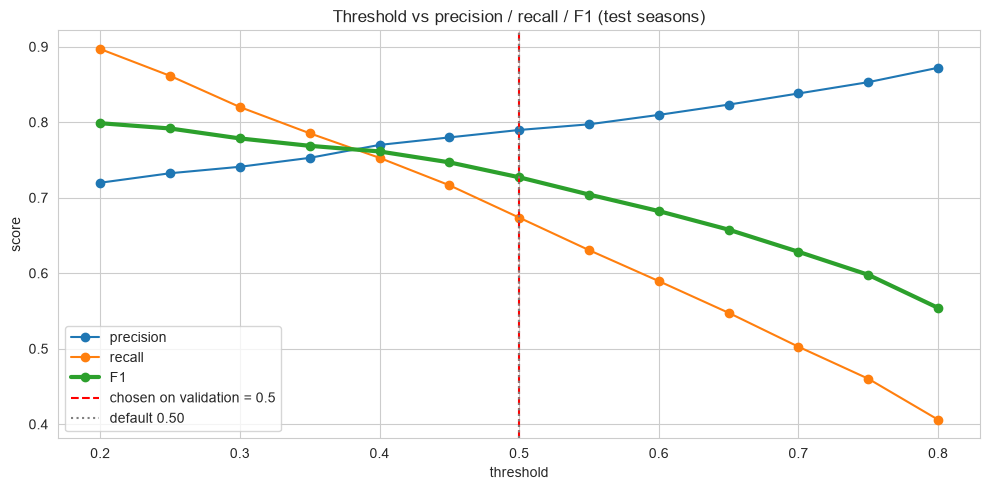

In [183]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_table['threshold'], threshold_table['test_precision'], marker='o', label='precision')
plt.plot(threshold_table['threshold'], threshold_table['test_recall'], marker='o', label='recall')
plt.plot(threshold_table['threshold'], threshold_table['test_f1'], marker='o', lw=3, label='F1')
plt.axvline(BEST_THRESHOLD, color='red', ls='--',
            label=f'chosen on validation = {BEST_THRESHOLD}')
plt.axvline(0.5, color='grey', ls=':', label='default 0.50')
plt.xlabel('threshold'); plt.ylabel('score')
plt.title('Threshold vs precision / recall / F1 (test seasons)')
plt.legend(); plt.tight_layout(); plt.show()

## 25. Interpretability


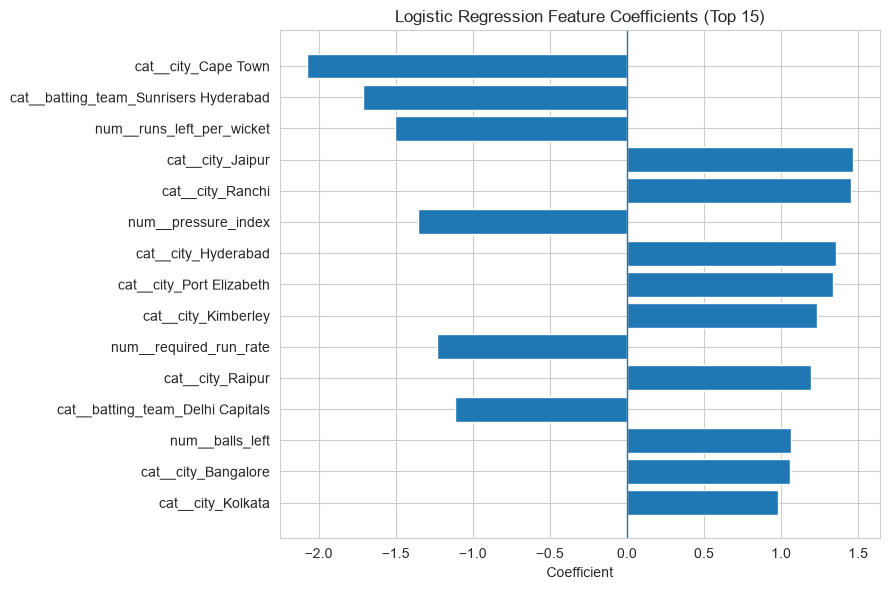

,feature,coefficient,abs_coefficient
17,cat__city_Cape Town,-2.0756,2.0756
6,cat__batting_team_Sunrisers Hyderabad,-1.7124,1.7124
53,num__runs_left_per_wicket,-1.5040,1.5040
28,cat__city_Jaipur,1.4647,1.4647
37,cat__city_Ranchi,1.4509,1.4509
55,num__pressure_index,-1.3573,1.3573
27,cat__city_Hyderabad,1.3572,1.3572
34,cat__city_Port Elizabeth,1.3360,1.3360
30,cat__city_Kimberley,1.2352,1.2352
46,num__required_run_rate,-1.2310,1.2310


In [ ]:


encoded_names = best_model.named_steps['preprocess'].get_feature_names_out()
coefficients = best_model.named_steps['model'].coef_[0]

importance = pd.DataFrame({
    'feature': encoded_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(9, 6))

top = importance.head(15).iloc[::-1]

plt.barh(
    top['feature'],
    top['coefficient']
)

plt.axvline(0, linewidth=1)
plt.title('Logistic Regression Feature Coefficients (Top 15)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

importance.head(15).round(4)

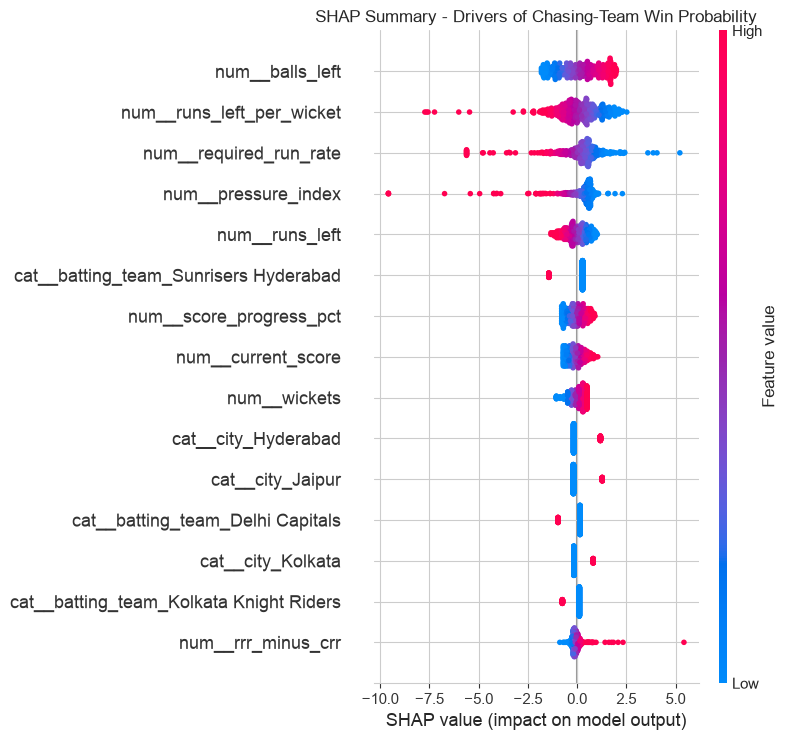

In [ ]:

import shap

shap_sample = test_df.sample(500, random_state=RANDOM_STATE)
shap_input = best_model.named_steps['preprocess'].transform(
    shap_sample[FEATURE_COLS]
)

model = best_model.named_steps['model']

explainer = shap.LinearExplainer(model, shap_input)
shap_values = explainer.shap_values(shap_input)

shap.summary_plot(
    shap_values,
    shap_input,
    feature_names=encoded_names,
    max_display=15,
    show=False
)

plt.title('SHAP Summary - Drivers of Chasing-Team Win Probability')
plt.tight_layout()
plt.show()

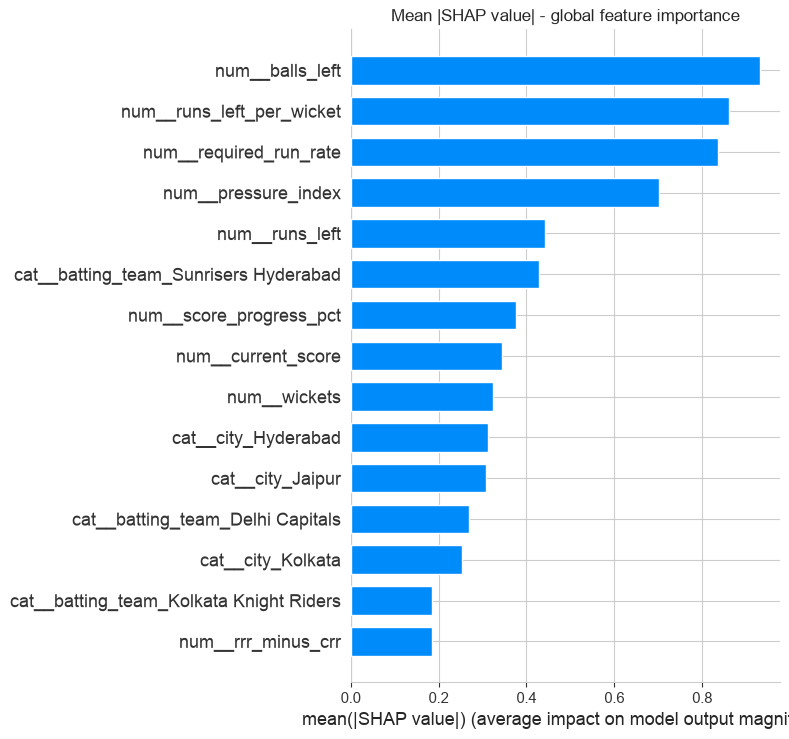

,feature,mean_abs_shap
43,num__balls_left,0.9305
53,num__runs_left_per_wicket,0.8600
46,num__required_run_rate,0.8362
55,num__pressure_index,0.7020
42,num__runs_left,0.4424
6,cat__batting_team_Sunrisers Hyderabad,0.4277
52,num__score_progress_pct,0.3758
41,num__current_score,0.3442
44,num__wickets,0.3235
27,cat__city_Hyderabad,0.3130


In [193]:
shap.summary_plot(shap_values, shap_input, feature_names=encoded_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('Mean |SHAP value| - global feature importance')
plt.tight_layout(); plt.show()

shap_ranking = pd.DataFrame({
    'feature': encoded_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)
shap_ranking.head(12).round(4)

In [ ]:

perm = permutation_importance(best_model, test_df.sample(4000, random_state=RANDOM_STATE)[FEATURE_COLS],
                              test_df.sample(4000, random_state=RANDOM_STATE)['result'],
                              n_repeats=3, random_state=RANDOM_STATE,
                              scoring='neg_log_loss', n_jobs=1)

perm_table = pd.DataFrame({
    'feature': FEATURE_COLS,
    'permutation_importance': perm.importances_mean,
}).sort_values('permutation_importance', ascending=False)
perm_table.round(4)

,feature,permutation_importance
6,balls_left,0.1654
16,runs_left_per_wicket,0.1057
9,required_run_rate,0.0956
18,pressure_index,0.0698
0,batting_team,0.0377
7,wickets,0.0222
2,city,0.0198
4,current_score,0.0135
5,runs_left,0.0132
15,score_progress_pct,0.0131


## 26. Error analysis

In [ ]:
error_df = test_df.copy()
error_df['predicted_prob'] = test_proba
error_df['predicted'] = (error_df['predicted_prob'] >= BEST_THRESHOLD).astype(int)
error_df['correct'] = (error_df['predicted'] == error_df['result']).astype(int)
error_df['abs_error'] = np.abs(error_df['predicted_prob'] - error_df['result'])

error_df['phase'] = pd.cut(error_df['balls_left'], [-1, 29, 59, 89, 120],
                           labels=['Death (0-29 left)', 'Middle-late (30-59)',
                                   'Middle (60-89)', 'Early (90-120)'])
phase_summary = error_df.groupby('phase', observed=True).agg(
    rows=('correct', 'size'), accuracy=('correct', 'mean'),
    mean_abs_error=('abs_error', 'mean'))
print('Performance by phase of the chase:')
print(phase_summary.round(4))

Performance by phase of the chase:
                     rows  accuracy  mean_abs_error
phase                                              
Death (0-29 left)    2946    0.8255          0.2169
Middle-late (30-59)  3551    0.7587          0.2913
Middle (60-89)       3555    0.6706          0.3632
Early (90-120)       3585    0.6170          0.4029


In [ ]:

wicket_summary = error_df.groupby(
    pd.cut(error_df['wickets'], [-1, 2, 4, 6, 8, 10],
           labels=['0-2', '3-4', '5-6', '7-8', '9-10']), observed=True
).agg(rows=('correct', 'size'), accuracy=('correct', 'mean'))
print('Performance by wickets in hand:')
print(wicket_summary.round(4))
confident = error_df[(error_df['predicted_prob'] > 0.9) | (error_df['predicted_prob'] < 0.1)]
print()
print(f'Confident predictions (>90% or <10%): {len(confident)}')
print(f'  of which wrong: {(confident["correct"] == 0).sum()} '
      f'({(1 - confident["correct"].mean()) * 100:.2f}%)')

Performance by wickets in hand:
         rows  accuracy
wickets                
0-2       284    0.9014
3-4       684    0.8041
5-6      2620    0.7527
7-8      4567    0.7729
9-10     5484    0.6227

Confident predictions (>90% or <10%): 4896
  of which wrong: 453 (9.25%)


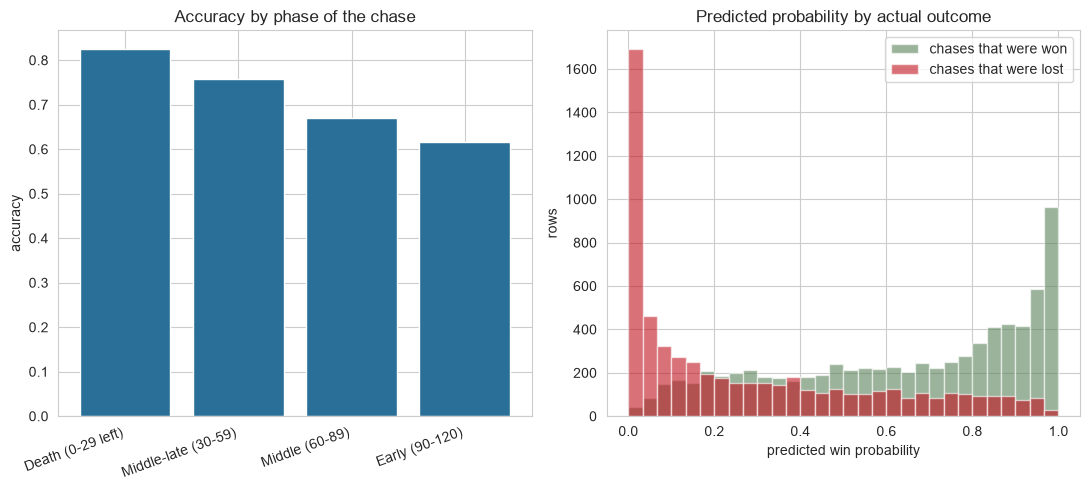

In [204]:
plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
plt.bar(phase_summary.index.astype(str), phase_summary['accuracy'], color='#2a6f97')
plt.xticks(rotation=20, ha='right'); plt.ylabel('accuracy')
plt.title('Accuracy by phase of the chase')

plt.subplot(1, 2, 2)
for outcome, label, colour in [(1, 'chases that were won', '#588157'),
                               (0, 'chases that were lost', '#c1121f')]:
    plt.hist(error_df.loc[error_df['result'] == outcome, 'predicted_prob'],
             bins=30, alpha=0.6, label=label, color=colour)
plt.xlabel('predicted win probability'); plt.ylabel('rows')
plt.title('Predicted probability by actual outcome')
plt.legend()
plt.tight_layout(); plt.show()

In [ ]:

worst = error_df.nlargest(8, 'abs_error')[
    ['match_id', 'Season', 'batting_team', 'bowling_team', 'runs_left',
     'balls_left', 'wickets', 'required_run_rate', 'predicted_prob', 'result']]
print('Worst 8 misses on the test seasons:')
worst.round(3)

Worst 8 misses on the test seasons:


,match_id,Season,batting_team,bowling_team,runs_left,balls_left,wickets,required_run_rate,predicted_prob,result
69822,11330,IPL-2019,Chennai Super Kings,Royal Challengers Bangalore,-7,1,3,-42.0,1.000,0
72141,11415,IPL-2019,Chennai Super Kings,Mumbai Indians,-5,1,4,-30.0,1.000,0
59206,7900,IPL-2018,Sunrisers Hyderabad,Mumbai Indians,4,1,1,24.0,0.000,1
59813,7905,IPL-2018,Chennai Super Kings,Kings XI Punjab,-2,1,5,-12.0,1.000,0
72140,11415,IPL-2019,Chennai Super Kings,Mumbai Indians,-3,2,4,-9.0,1.000,0
63256,7936,IPL-2018,Rajasthan Royals,Chennai Super Kings,8,1,4,48.0,0.001,1
72139,11415,IPL-2019,Chennai Super Kings,Mumbai Indians,-2,3,5,-4.0,0.999,0
59812,7905,IPL-2018,Chennai Super Kings,Kings XI Punjab,-2,2,5,-6.0,0.999,0


## 27. Saving the final model

One artifact containing **preprocessing + model**, so the Streamlit app can never
preprocess differently from this notebook.

In [210]:
os.makedirs('models', exist_ok=True)

final_metrics = evaluate_model(best_model, X_test, y_test, threshold=BEST_THRESHOLD)
final_metrics = {k: round(v, 4) for k, v in final_metrics.items()}
print('Final test metrics at threshold', BEST_THRESHOLD)
for k, v in final_metrics.items():
    print(f'  {k:10s} {v}')

metadata = {
    'model_name': BEST_MODEL_NAME,
    'target': 'result (1 = chasing team wins, 0 = chasing team loses)',
    'feature_columns': FEATURE_COLS,
    'categorical_columns': CAT_COLS,
    'numerical_columns': NUM_COLS,
    'classification_threshold': float(BEST_THRESHOLD),
    'threshold_selected_on': 'IPL-2017 validation season (test set untouched)',
    'teams': ACTIVE_TEAMS,
    'cities': sorted(train_df['city'].unique().tolist()),
    'train_seasons': train_seasons,
    'validation_seasons': val_seasons,
    'test_seasons': test_seasons,
    'n_train_rows': int(len(train_df)), 'n_train_matches': int(train_df['match_id'].nunique()),
    'n_val_rows': int(len(val_df)),     'n_val_matches': int(val_df['match_id'].nunique()),
    'n_test_rows': int(len(test_df)),   'n_test_matches': int(test_df['match_id'].nunique()),
    'test_metrics': final_metrics,
    'calibration': 'none - isotonic and sigmoid both worsened test log loss',
    'sklearn_note': 'the pipeline imports clip_extreme_rates from cricket_utils.py; keep that file alongside the model',
}

joblib.dump(best_model, 'models/best_cricket_model.pkl')
with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print()
print('Saved models/best_cricket_model.pkl')
print('Saved models/model_metadata.json')

Final test metrics at threshold 0.5
  Accuracy   0.7129
  Precision  0.7897
  Recall     0.6736
  F1         0.727
  ROC-AUC    0.8158
  LogLoss    0.5621
  Brier      0.1896

Saved models/best_cricket_model.pkl
Saved models/model_metadata.json


In [ ]:

reloaded = joblib.load('models/best_cricket_model.pkl')
with open('models/model_metadata.json') as f:
    reloaded_metadata = json.load(f)

sample_state = build_match_state(
    batting_team='Mumbai Indians', bowling_team='Chennai Super Kings', city='Mumbai',
    target_score=180, current_score=120, balls_completed=90, wickets_lost=4)

assert list(sample_state.columns) == reloaded_metadata['feature_columns'], 'feature mismatch!'

probabilities = reloaded.predict_proba(sample_state)[0]
print('Sample situation: 120/4 after 15 overs, chasing 180')
print(f'  Mumbai Indians      {probabilities[1]*100:.1f}%')
print(f'  Chennai Super Kings {probabilities[0]*100:.1f}%')
print(f'  probabilities sum to {probabilities.sum():.6f}')
print()
print('Feature order matches metadata: OK')

Sample situation: 120/4 after 15 overs, chasing 180
  Mumbai Indians      35.7%
  Chennai Super Kings 64.3%
  probabilities sum to 1.000000

Feature order matches metadata: OK


## 28. Match progression analysis



In [215]:
def match_progression(second_innings_df, match_id, pipe):
    """Over-by-over win probability for one chase.

    Takes the last row of each over (the state at the end of that over) and asks the
    model for the batting team's win probability there.
    """
    match = second_innings_df[second_innings_df['match_id'] == match_id].copy()
    if match.empty:
        raise ValueError(f'match_id {match_id} not found in the second-innings data')

    match = match.sort_values(['over', 'ball'])
    end_of_over = match.groupby('over').tail(1).copy()

    probabilities = pipe.predict_proba(end_of_over[FEATURE_COLS])
    end_of_over['lose_pct'] = np.round(probabilities[:, 0] * 100, 1)
    end_of_over['win_pct'] = np.round(probabilities[:, 1] * 100, 1)

    per_over = (match.groupby('over')
                .agg(runs_in_over=('total_runs', 'sum'),
                     wickets_in_over=('is_wicket', 'sum'))
                .reset_index())

    progression = end_of_over[['over', 'current_score', 'runs_left', 'wickets',
                               'win_pct', 'lose_pct']].merge(per_over, on='over')
    progression = progression.rename(columns={'over': 'end_of_over',
                                              'wickets': 'wickets_in_hand'})
    return progression, int(match['target_score'].iloc[0])

In [ ]:
def plot_match_progression(progression, target, batting_team, bowling_team):
    fig, ax1 = plt.subplots(figsize=(14, 6))

    ax1.bar(progression['end_of_over'], progression['runs_in_over'],
            color='#c9d6df', label='runs in over')
    ax1.set_xlabel('End of over'); ax1.set_ylabel('runs / wickets in the over')
    ax1.set_ylim(0, max(30, progression['runs_in_over'].max() + 5))

    wicket_overs = progression[progression['wickets_in_over'] > 0]
    ax1.scatter(wicket_overs['end_of_over'],
                np.zeros(len(wicket_overs)) + 1,
                marker='X', s=140, color='black', zorder=5, label='wicket fell')

    ax2 = ax1.twinx()
    ax2.plot(progression['end_of_over'], progression['win_pct'], color='#2d6a4f',
             lw=3, marker='o', label=f'{batting_team} win %')
    ax2.plot(progression['end_of_over'], progression['lose_pct'], color='#c1121f',
             lw=3, marker='o', label=f'{bowling_team} win %')
    ax2.axhline(50, color='grey', ls='--', lw=1)
    ax2.set_ylabel('win probability (%)'); ax2.set_ylim(0, 100)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f'Win probability through the chase - target {target}')
    plt.tight_layout(); plt.show()

In [ ]:

second_innings_for_plot = second_innings[second_innings['balls_left'] != 0]

example_match_id = 7894     
match_row = matches_clean[matches_clean['id'] == example_match_id].iloc[0]
chase_row = second_innings_for_plot[second_innings_for_plot['match_id'] == example_match_id].iloc[0]
progression, target = match_progression(second_innings_for_plot, example_match_id, best_model)
print(f'{chase_row["batting_team"]} chasing {target} vs {chase_row["bowling_team"]} '
      f'at {match_row["city"]} ({match_row["Season"]})')
print(f'Actual winner: {match_row["winner"]}')
print()
progression

Chennai Super Kings chasing 169 vs Mumbai Indians at Mumbai (IPL-2018)
Actual winner: Chennai Super Kings



,end_of_over,current_score,runs_left,wickets_in_hand,win_pct,lose_pct,runs_in_over,wickets_in_over
0,1,7,162,10,53.1,46.9,7,0
1,2,16,153,10,58.9,41.1,9,0
2,3,19,150,10,54.9,45.1,3,0
3,4,31,138,9,52.0,48.0,12,1
4,5,39,130,9,55.1,44.9,8,0
5,6,42,127,8,36.9,63.1,3,1
6,7,44,125,7,18.9,81.1,2,1
7,8,50,119,7,19.5,80.5,6,0
8,9,52,117,6,7.9,92.1,2,1
9,10,58,111,6,8.0,92.0,6,0


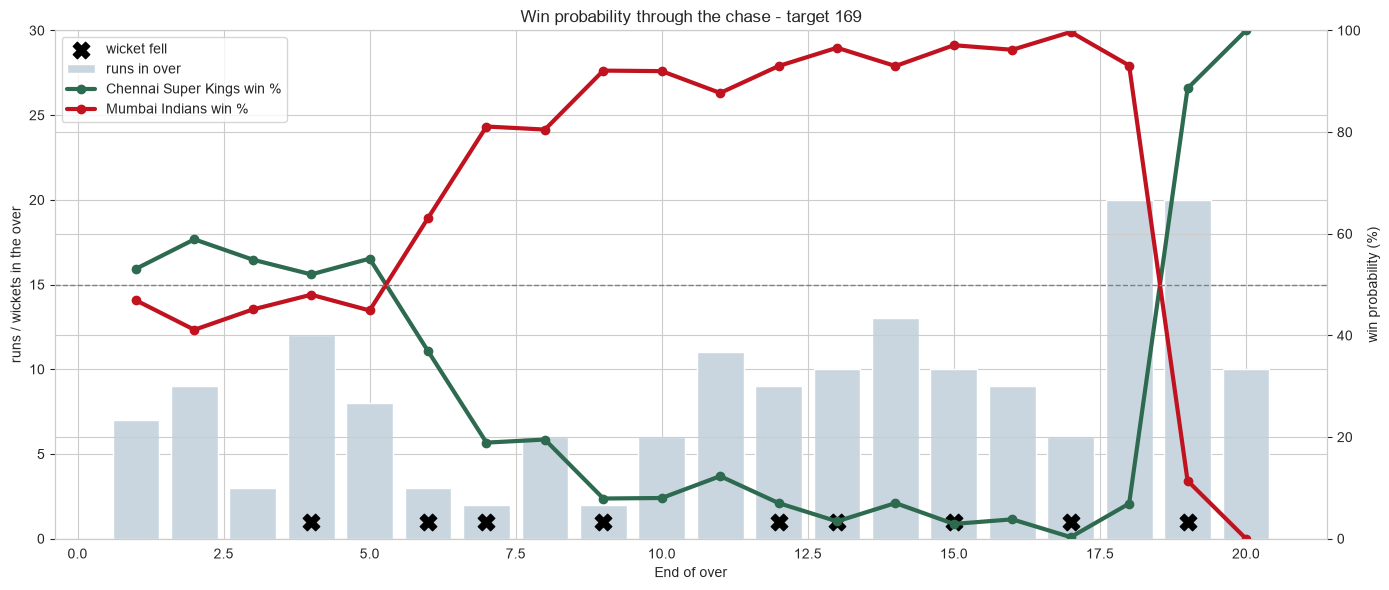

In [221]:
plot_match_progression(progression, target,
                       chase_row['batting_team'], chase_row['bowling_team'])

### Reading this chase

Chennai Super Kings chasing 198 vs Kings XI Punjab


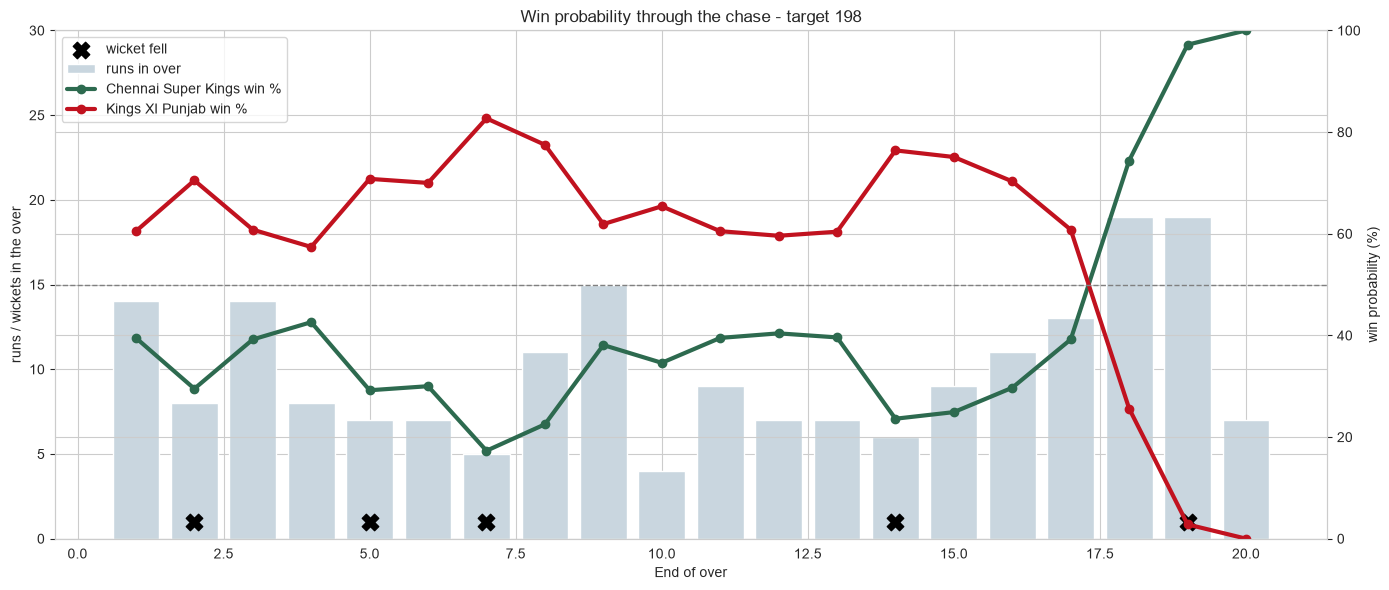

In [ ]:

other_match_id = int(test_df['match_id'].unique()[10])
other_chase = second_innings_for_plot[second_innings_for_plot['match_id'] == other_match_id].iloc[0]
other_prog, other_target = match_progression(second_innings_for_plot, other_match_id, best_model)

print(f'{other_chase["batting_team"]} chasing {other_target} vs {other_chase["bowling_team"]}')
plot_match_progression(other_prog, other_target,
                       other_chase['batting_team'], other_chase['bowling_team'])